In [40]:
 # Required packages
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.pyplot as plt
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split



```
de → 0
es → 1
fr → 2
it → 3
```



# Data Loading

In [41]:
# this has both L2 and TR from previous experiments

df = pd.read_csv("https://raw.githubusercontent.com/happy522/Shining-Through/refs/heads/main/Implementation/TR1%20and%20L2/L2_TR.csv")

df = df.drop(columns=["Unnamed: 0","sentlength","alang","akorp","afile"],axis = "columns")
df = df.rename(columns={"astatus": "dataset_name"})

num_cols = df.select_dtypes(include='number').columns
numerical_cols = [c for c in num_cols if c not in ['L1']]
print("Numeric feature columns:", numerical_cols)

# Count of L1 per L2
count_per_L2 = df.groupby("dataset_name")["L1"].value_counts().unstack(fill_value=0)

print(count_per_L2)

# Data balancing across entire data set
L2 = df[df['dataset_name'] == 'L2']
TR1 = df[df['dataset_name'] == 'TR']


""" concating lets do it afterwards!
df_balanced_1100 = pd.concat([df_L2, df_TR_downsampled_1100], ignore_index=True)"""


# Europarl data

TR2 = pd.read_csv("https://raw.githubusercontent.com/happy522/Shining-Through/refs/heads/main/Data%20Generation/Datasets/europarl/europarl_all_data.csv")

TR2 = TR2.drop(columns="sentlength",axis = "columns")
TR2 = TR2.drop(columns=["Unnamed: 0","alang","akorp","afile","astatus"],axis = "columns")


num_cols = TR2.select_dtypes(include='number').columns
numerical_cols = [c for c in num_cols if c not in ['L1']]
print("Numeric feature columns:", numerical_cols)

TR1["dataset_name"] = "TR1"
TR2["dataset_name"] = "TR2"
L2["dataset_name"] = "L2"


df = pd.concat([TR1, L2, TR2], axis=0, ignore_index=True)

Numeric feature columns: ['ppron', 'possdet', 'indef', 'cconj', 'whconj', 'relativ', 'pied', 'correl', 'copula', 'attrib', 'pasttense', 'lexdens', 'lexTTR', 'mquantif', 'mpred', 'finites', 'infs', 'pverbals', 'deverbals', 'bypassives', 'longpassives', 'sconj', 'addit', 'advers', 'caus', 'tempseq', 'epist', 'but', 'comp', 'sup', 'neg', 'numcls', 'simple', 'demdets', 'nnargs', 'mhd', 'mdd', 'acl', 'aux', 'aux:pass', 'ccomp', 'nsubj:pass', 'parataxis', 'xcomp']
L1               de     es     fr    it
dataset_name                           
L2             1100   1100   1100  1100
TR            27743  18604  89626  2167
Numeric feature columns: ['ppron', 'possdet', 'indef', 'cconj', 'whconj', 'relativ', 'pied', 'correl', 'copula', 'attrib', 'pasttense', 'lexdens', 'lexTTR', 'mquantif', 'mpred', 'finites', 'infs', 'pverbals', 'deverbals', 'bypassives', 'longpassives', 'sconj', 'addit', 'advers', 'caus', 'tempseq', 'epist', 'but', 'comp', 'sup', 'neg', 'numcls', 'simple', 'demdets', 'nnargs',

/tmp/ipykernel_5364/638264445.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  TR1["dataset_name"] = "TR1"
/tmp/ipykernel_5364/638264445.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  L2["dataset_name"] = "L2"


In [42]:
num_cols = df.select_dtypes(include='number').columns
numerical_cols = [c for c in num_cols if c not in ['L1']]

print("Numeric feature columns:", numerical_cols)


Numeric feature columns: ['ppron', 'possdet', 'indef', 'cconj', 'whconj', 'relativ', 'pied', 'correl', 'copula', 'attrib', 'pasttense', 'lexdens', 'lexTTR', 'mquantif', 'mpred', 'finites', 'infs', 'pverbals', 'deverbals', 'bypassives', 'longpassives', 'sconj', 'addit', 'advers', 'caus', 'tempseq', 'epist', 'but', 'comp', 'sup', 'neg', 'numcls', 'simple', 'demdets', 'nnargs', 'mhd', 'mdd', 'acl', 'aux', 'aux:pass', 'ccomp', 'nsubj:pass', 'parataxis', 'xcomp']


# Information related to data

In [43]:
l1_values = ["es", "de", "fr", "it"]
df_filtered = df[df["L1"].isin(l1_values)]

# Count of L1 per L2
count_per_L2 = df_filtered.groupby("dataset_name")["L1"].value_counts().unstack(fill_value=0)

print(count_per_L2)



L1               de     es     fr    it
dataset_name                           
L2             1100   1100   1100  1100
TR1           27743  18604  89626  2167
TR2             479    272    476   463


In [44]:
# smallest sample in Europarl is of 272 (Es) hence downsampling every data
TR1_balanced = (
    TR1
    .groupby('L1', group_keys=False)
    .sample(n=272, random_state=42)
)

L2_balanced = (
    L2
    .groupby('L1', group_keys=False)
    .sample(n=272, random_state=42)
)


TR2_balanced = (
    TR2
    .groupby('L1', group_keys=False)
    .sample(n=272, random_state=42)
)

df_balanced = pd.concat([TR1_balanced, L2_balanced, TR2_balanced], axis=0, ignore_index=True)

#SelectKBEST

In [45]:
def selectkbest_analysis(
    df,
    target_col='L1',
    cols_to_drop=None,
    classes=None,
    k=10,
    output_dir='',
    zip_output=True
):

    DEFAULT_DROP = ['L1', 'dataset_name', 'cluster', 'kmeans_labels']
    all_to_drop  = list(set(DEFAULT_DROP + (cols_to_drop or [])))

    df_balanced  = df.copy().dropna()

    feature_cols = [c for c in df_balanced.columns if c not in all_to_drop]

    X_s          = df_balanced[feature_cols].apply(pd.to_numeric, errors='coerce').fillna(0).values
    y_balanced   = df_balanced[target_col].values

    # 1. Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_s, y_balanced, stratify=y_balanced, random_state=42
    )

    # 2. Build class labels
    df_plot = df_balanced.copy()

    if 'dataset_name' in df_plot.columns:
        df_plot['class'] = (
            df_plot['dataset_name'].astype(str) + "_" +
            df_plot[target_col].astype(str)
        )
    else:
        df_plot['class'] = df_plot[target_col].astype(str)

    if classes is None:
        classes = sorted(df_plot['class'].unique().tolist())

    # 3. SelectKBest
    selector     = SelectKBest(score_func=f_classif, k=k)
    selector.fit(X_s, y_balanced)
    top_idx      = selector.get_support(indices=True)
    top_features = [feature_cols[i] for i in top_idx]

    print(f"[{output_dir}] Top {k} features by ANOVA F-test: {top_features}")

    # 4. Output directory
    os.makedirs(output_dir, exist_ok=True)

    for f in top_features:
        df_plot[f] = pd.to_numeric(df_plot[f], errors='coerce')

    # 5. Boxplots
    for feat in top_features:
        fig, ax = plt.subplots(figsize=(8, 4))
        sns.boxplot(x='class', y=feat, data=df_plot, order=classes, ax=ax)
        ax.set_title(feat)
        ax.set_xlabel("")
        ax.tick_params(axis='x', rotation=45)
        plt.tight_layout()
        fig.savefig(os.path.join(output_dir, f"{feat}_boxplot.png"), dpi=300)
        plt.close(fig)

    # 6. KDE plots
    for feat in top_features:
        fig, ax = plt.subplots(figsize=(8, 4))
        for cls in classes:
            subset = df_plot[df_plot['class'] == cls]
            if not subset.empty:
                sns.kdeplot(subset[feat], label=cls, fill=True, alpha=0.4, ax=ax)
        ax.set_title(f"KDE of {feat} by class")
        ax.set_xlabel(feat)
        ax.set_ylabel("Density")
        ax.legend()
        plt.tight_layout()
        fig.savefig(os.path.join(output_dir, f"{feat}_KDE.png"), dpi=300)
        plt.close(fig)

    # 7. Feature importance bar chart
    f_scores = selector.scores_[top_idx]
    p_values = selector.pvalues_[top_idx]

    importance_df = pd.DataFrame({
        'Feature': top_features,
        'F_score': f_scores,
        'p_value': p_values
    }).sort_values(by='F_score', ascending=False)

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.barplot(x='F_score', y='Feature', data=importance_df, ax=ax)
    ax.set_xlabel("ANOVA F-score")
    ax.set_ylabel("Feature")
    ax.set_title(f"Feature Importance - SelectKBest: ({output_dir})")
    plt.tight_layout()
    fig.savefig(os.path.join(output_dir, "Top_Feature_Importance_desc.png"), dpi=300)
    plt.show()
    plt.close(fig)

    # 8. zip
    if zip_output:
        os.system(f"zip -r {output_dir}.zip {output_dir}")
        print(f"Saved → {output_dir}.zip")


    return importance_df, top_features

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [13] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


[L2] Top 10 features by ANOVA F-test: ['cconj', 'relativ', 'copula', 'lexdens', 'lexTTR', 'numcls', 'mhd', 'mdd', 'ccomp', 'parataxis']


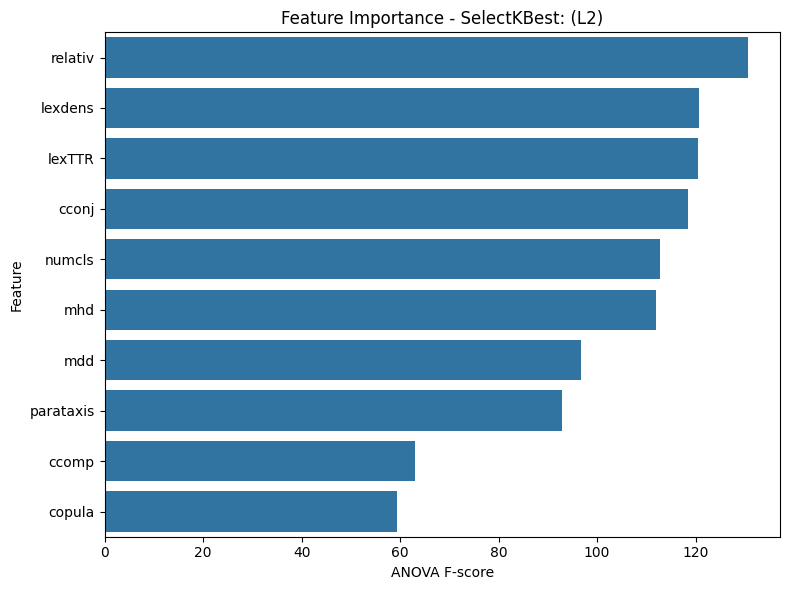

Saved → L2.zip


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [13] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


[TR1] Top 10 features by ANOVA F-test: ['cconj', 'attrib', 'lexdens', 'lexTTR', 'numcls', 'demdets', 'nnargs', 'mhd', 'mdd', 'parataxis']


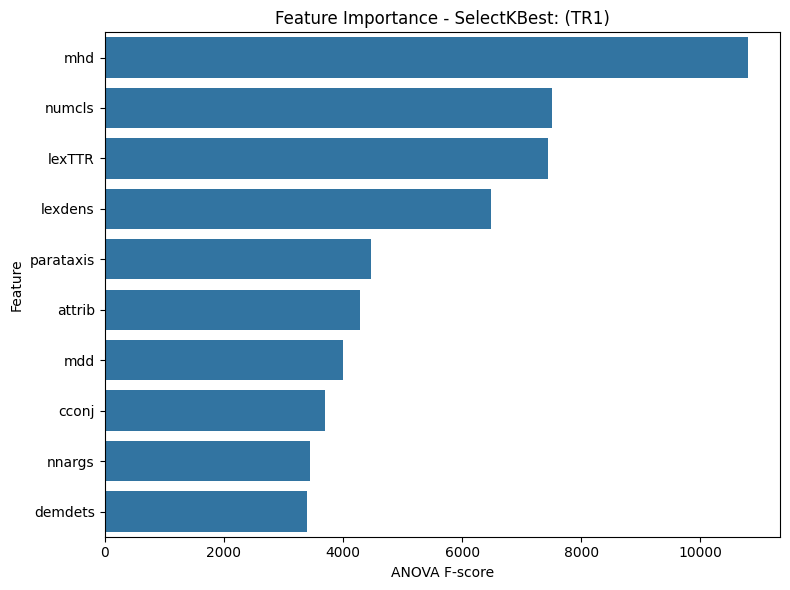

Saved → TR1.zip
[TR2] Top 10 features by ANOVA F-test: ['cconj', 'relativ', 'attrib', 'pasttense', 'finites', 'pverbals', 'numcls', 'simple', 'mhd', 'mdd']


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [13] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


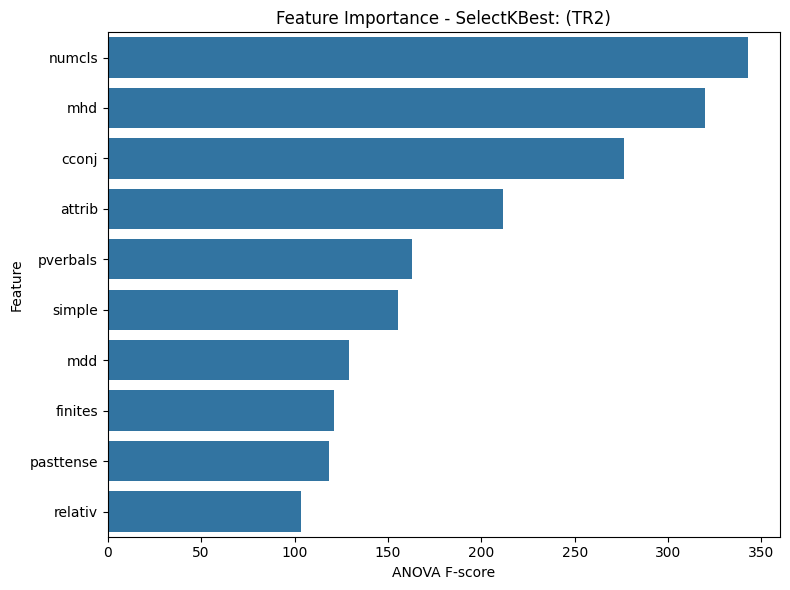

Saved → TR2.zip
[Combind L2 + TR1 + TR2 (Balanced)] Top 10 features by ANOVA F-test: ['cconj', 'relativ', 'attrib', 'lexdens', 'lexTTR', 'numcls', 'simple', 'mhd', 'mdd', 'parataxis']


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [13] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


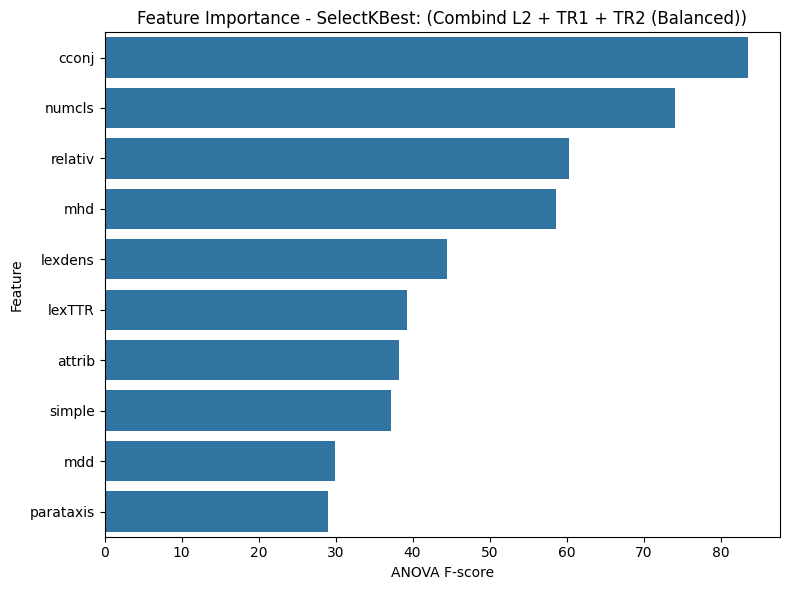

Saved → Combind L2 + TR1 + TR2 (Balanced).zip
[Combind L2 + TR1 + TR2] Top 10 features by ANOVA F-test: ['cconj', 'relativ', 'copula', 'lexdens', 'lexTTR', 'numcls', 'mhd', 'mdd', 'ccomp', 'parataxis']


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [13] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


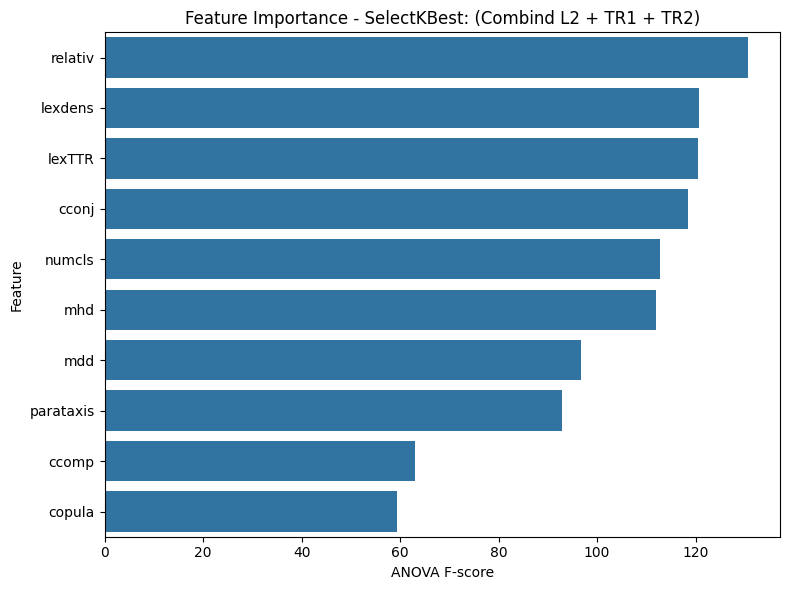

Saved → Combind L2 + TR1 + TR2.zip


In [50]:
CLASSES_MAP = {
    "L2":                                ["L2_es",  "L2_de",  "L2_fr",  "L2_it"],
    "TR1":                               ["TR1_es", "TR1_de", "TR1_fr", "TR1_it"],
    "TR2":                               ["TR2_es", "TR2_de", "TR2_fr", "TR2_it"],
    "Combind L2 + TR1 + TR2 (Balanced)": ["L2_es","L2_de","L2_fr","L2_it",
                                          "TR1_es","TR1_de","TR1_fr","TR1_it",
                                          "TR2_es","TR2_de","TR2_fr","TR2_it"],
    "Combind L2 + TR1 + TR2":            ["L2_es","L2_de","L2_fr","L2_it",
                                          "TR1_es","TR1_de","TR1_fr","TR1_it",
                                          "TR2_es","TR2_de","TR2_fr","TR2_it"],
}

dataframes = {
    "L2":                                L2,
    "TR1":                               TR1,
    "TR2":                               TR2,
    "Combind L2 + TR1 + TR2 (Balanced)": df_balanced,
    "Combind L2 + TR1 + TR2":            df,
}

results = {}
for name, df in dataframes.items():
    imp_df, top_feats = selectkbest_analysis(
        df         = df,
        classes    = CLASSES_MAP[name],   # ← correct classes per df
        k          = 10,
        output_dir = name,
    )
    results[name] = {"importance": imp_df, "top_features": top_feats}